## Initialization

initialization handles all imports and settings

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
%matplotlib inline

## Load data

Just the data and naming them.

In [ ]:
calls_df = pd.read_csv('/datasets/megaline_calls.csv')
internet_df = pd.read_csv('/datasets/megaline_internet.csv')
messages_df = pd.read_csv('/datasets/megaline_messages.csv')
plans_df = pd.read_csv('/datasets/megaline_plans.csv')
users_df = pd.read_csv('/datasets/megaline_users.csv')         
# Load the data files into different DataFrames

## Prepare the data

## Plans

In [ ]:
plans_df.info()
# Print the general/summary information about the plans' DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
plans_df.head()
# Print a sample of data for plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


What I observed:
- There are no missing data: All columns show "2 non-null." 
- It has the correct data types in64 and float64. 
- Surf and Ultimate are lower case. 
- A negative may be that the data shows "mb_per_month_included" but pricing is "usd_per_gb" this may cause isuses.

## Fix data

In [ ]:
plans_df['usd_per_mb'] = plans_df['usd_per_gb'] / 1024

print("Before and after conversion:")
print(plans_df[['plan_name', 'usd_per_gb', 'usd_per_mb']])

Before and after conversion:
  plan_name  usd_per_gb  usd_per_mb
0      surf          10        0.01
1  ultimate           7        0.01


## Users

In [ ]:
users_df.info()
# Print the general/summary information about the users' DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
users_df.head()
# Print a sample of data for users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


What I noticed: 
- 500 non-Null and 34 non-Null this means there are 466 active users and 34 have left the service.
- I should Convert date columns to datetime.
- Add proper date %Y-%m-%d, incase any dates are other order. 

### Fix Data

Dates converted from object to datetime for analysis

In [ ]:
users_df['reg_date'] = pd.to_datetime(users_df['reg_date'], format='%Y-%m-%d')
users_df['churn_date'] = pd.to_datetime(users_df['churn_date'], format='%Y-%m-%d')

print(users_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


### Enrich Data

In [ ]:
users_df.head() # verifying that churn_date is mostly NaT

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT


## Calls

In [ ]:
# Print the general/summary information about the calls' DataFrame
calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Print a sample of data for calls
calls_df.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


What I noticed:
- Duration is in minutes and should be whole numbers or int
- Duration rounded up per Megaline's policy (even 0.1 minutes = 1 minute)

### Fix data

In [ ]:
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'], format='%Y-%m-%d')
calls_df['duration'] = np.ceil(calls_df['duration']).astype(int)

# Verifying changes
print(calls_df.info())
print("\n=== Sample Data ===")
print(calls_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.2+ MB
None

=== Sample Data ===
         id  user_id  call_date  duration
0   1000_93     1000 2018-12-27         9
1  1000_145     1000 2018-12-27        14
2  1000_247     1000 2018-12-27        15
3  1000_309     1000 2018-12-28         6
4  1000_380     1000 2018-12-30         5


### Enrich data

Creates periods like 2018-01, 2018-02, etc.

In [ ]:
calls_df['year_month'] = calls_df['call_date'].dt.to_period('M')
calls_df.head()

,id,user_id,call_date,duration,year_month
0,1000_93,1000,2018-12-27,9,2018-12
1,1000_145,1000,2018-12-27,14,2018-12
2,1000_247,1000,2018-12-27,15,2018-12
3,1000_309,1000,2018-12-28,6,2018-12
4,1000_380,1000,2018-12-30,5,2018-12


## Messages

In [ ]:
# Print the general/summary information about the messages' DataFrame
messages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Print a sample of data for messages
messages_df.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


What I noticed:
- It will need the year_month column and message_date

### Fix data

Converted the message_date column to datetime format and created the year_month

In [ ]:
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'], format='%Y-%m-%d')
messages_df['year_month'] = messages_df['message_date'].dt.to_period('M')

print(messages_df.info())
print("\n=== Sample Data ===")
print(messages_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   year_month    76051 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1)
memory usage: 2.3+ MB
None

=== Sample Data ===
         id  user_id message_date year_month
0  1000_125     1000   2018-12-27    2018-12
1  1000_160     1000   2018-12-31    2018-12
2  1000_223     1000   2018-12-31    2018-12
3  1000_251     1000   2018-12-27    2018-12
4  1000_255     1000   2018-12-26    2018-12


### Enrich data

- day_of_week: The name of the day (Monday, Tuesday, etc.)
- is_weekend: Boolean indicating if it's a weekend
- day_of_month: The day number within the month
- quarter: Which quarter of the year

In [ ]:
messages_df['day_of_week'] = messages_df['message_date'].dt.day_name()
messages_df['is_weekend'] = messages_df['message_date'].dt.weekday >= 5

messages_df['day_of_month'] = messages_df['message_date'].dt.day
messages_df['quarter'] = messages_df['message_date'].dt.quarter

print(messages_df.info())
print("\n=== Sample Data ===")
print(messages_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   year_month    76051 non-null  period[M]     
 4   day_of_week   76051 non-null  object        
 5   is_weekend    76051 non-null  bool          
 6   day_of_month  76051 non-null  int64         
 7   quarter       76051 non-null  int64         
dtypes: bool(1), datetime64[ns](1), int64(3), object(2), period[M](1)
memory usage: 4.1+ MB
None

=== Sample Data ===
         id  user_id message_date year_month day_of_week  is_weekend  \
0  1000_125     1000   2018-12-27    2018-12    Thursday       False   
1  1000_160     1000   2018-12-31    2018-12      Monday       False   
2  1000_223     1000   2018-12-31    2018-12      Monday  

## Internet

In [ ]:
# Print the general/summary information about the internet DataFrame

internet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Print a sample of data for the internet traffic

internet_df.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


What I noticed:
- Convert session_date to datetime
- Add year_month column
- Need to convert MB to GB and round up

### Fix data

Takes the session_date column and converts it from text (string) into a datetime object.
Shows the date range of the data.


In [ ]:
# Converts session_date from string to datetime
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'], format='%Y-%m-%d')

# Adds year_month for monthly aggregation
internet_df['year_month'] = internet_df['session_date'].dt.to_period('M')

# NOTE: mb_used is kept as float - per project rules, individual sessions are NOT rounded
# MB to GB conversion and rounding will happen AFTER monthly aggregation
# (Project: "individual web sessions are not rounded up. Instead, the total for the month is rounded up")

print(internet_df.info())
print("\n=== Sample Data ===")
print(internet_df.head(10))
print(f"\nDate range: {internet_df['session_date'].min()} to {internet_df['session_date'].max()}")
print(f"\nMB usage range:")
print(f"Min: {internet_df['mb_used'].min()}")
print(f"Max: {internet_df['mb_used'].max()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   year_month    104825 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 4.0+ MB
None

=== Sample Data ===
         id  user_id session_date  mb_used year_month
0   1000_13     1000   2018-12-29    89.86    2018-12
1  1000_204     1000   2018-12-31     0.00    2018-12
2  1000_379     1000   2018-12-28   660.40    2018-12
3  1000_413     1000   2018-12-26   270.99    2018-12
4  1000_442     1000   2018-12-27   880.22    2018-12
5    1001_0     1001   2018-08-24   284.68    2018-08
6    1001_3     1001   2018-12-09 

## Study plan conditions

Transforms data into monthly summaries, rounding is handled, before moving on to the monthly aggregations.

In [ ]:
# Calculate the monthly revenue for each user
print("=== Plan Conditions ===")
print(plans_df)

print("\n=== Plan Summary ===")
for index, row in plans_df.iterrows():
    print(f"\n{row['plan_name'].upper()} Plan:")
    print(f"  Monthly Fee: ${row['usd_monthly_pay']}")  # Fixed: changed from usd_monthly_fee
    print(f"  Included Minutes: {row['minutes_included']}")
    print(f"  Included Messages: {row['messages_included']}")
    print(f"  Included Data: {row['mb_per_month_included']/1024:.0f} GB")
    print(f"  Overage - Per Minute: ${row['usd_per_minute']}")
    print(f"  Overage - Per Message: ${row['usd_per_message']}")
    print(f"  Overage - Per GB: ${row['usd_per_gb']}")

print("\n=== Rounding Rules (per project requirements) ===")
print("- Calls: Each individual call rounded UP to nearest minute")
print("- Messages: Counted as-is (whole numbers)")
print("- Internet: Monthly total MB converted to GB and rounded UP")

=== Plan Conditions ===
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   usd_per_mb  
0        0.01  
1        0.01  

=== Plan Summary ===

SURF Plan:
  Monthly Fee: $20
  Included Minutes: 500
  Included Messages: 50
  Included Data: 15 GB
  Overage - Per Minute: $0.03
  Overage - Per Message: $0.03
  Overage - Per GB: $10

ULTIMATE Plan:
  Monthly Fee: $70
  Included Minutes: 3000
  Included Messages: 1000
  Included Data: 30 GB
  Overage - Per Minute: $0.01
  Overage - Per Message: $0.01
  Overage - Per GB: $7

=== Rounding Rules (per project requirements) ===
- Calls: Each individual call rounded UP to nea

## Aggregate data per user

Groups calls by user and month to calculate total minutes and number of calls.

In [ ]:
# Calculate the monthly revenue for each user

monthly_calls = calls_df.groupby(['user_id', 'year_month'])['duration'].agg([
    ('total_minutes', 'sum'),
    ('num_calls', 'count')
]).reset_index()
# total messages per user per month
monthly_messages = messages_df.groupby(['user_id', 'year_month']).size().reset_index(name='total_messages')
# total MB per user per month, converted to GB and round UP
monthly_internet = internet_df.groupby(['user_id', 'year_month'])['mb_used'].sum().reset_index(name='total_mb')
monthly_internet['total_gb'] = np.ceil(monthly_internet['total_mb'] / 1024).astype(int)
# Verifying
print("=== Monthly Calls ===")
print(monthly_calls.head(10))
print(f"\nShape: {monthly_calls.shape}")
print("\n=== Monthly Messages ===")
print(monthly_messages.head(10))
print(f"\nShape: {monthly_messages.shape}")
print("\n=== Monthly Internet ===")
print(monthly_internet.head(10))
print(f"\nShape: {monthly_internet.shape}") 

=== Monthly Calls ===
   user_id year_month  total_minutes  num_calls
0     1000    2018-12            124         16
1     1001    2018-08            182         27
2     1001    2018-09            315         49
3     1001    2018-10            393         65
4     1001    2018-11            426         64
5     1001    2018-12            412         56
6     1002    2018-10             59         11
7     1002    2018-11            386         55
8     1002    2018-12            384         47
9     1003    2018-12           1104        149

Shape: (2258, 4)

=== Monthly Messages ===
   user_id year_month  total_messages
0     1000    2018-12              11
1     1001    2018-08              30
2     1001    2018-09              44
3     1001    2018-10              53
4     1001    2018-11              36
5     1001    2018-12              44
6     1002    2018-10              15
7     1002    2018-11              32
8     1002    2018-12              41
9     1003    2018-12     

In [ ]:
# Calculates the number of calls and total minutes per user per month
monthly_calls = calls_df.groupby(['user_id', 'year_month'])['duration'].agg([
    ('total_minutes', 'sum'),
    ('num_calls', 'count')
]).reset_index()

print("=== Monthly Calls Aggregation ===")
print(monthly_calls.head(10))
print(f"\nShape: {monthly_calls.shape}")
print(f"\nColumns: {list(monthly_calls.columns)}")

=== Monthly Calls Aggregation ===
   user_id year_month  total_minutes  num_calls
0     1000    2018-12            124         16
1     1001    2018-08            182         27
2     1001    2018-09            315         49
3     1001    2018-10            393         65
4     1001    2018-11            426         64
5     1001    2018-12            412         56
6     1002    2018-10             59         11
7     1002    2018-11            386         55
8     1002    2018-12            384         47
9     1003    2018-12           1104        149

Shape: (2258, 4)

Columns: ['user_id', 'year_month', 'total_minutes', 'num_calls']


In [ ]:
# Calculates the number of text messages sent by each user per month
monthly_messages = messages_df.groupby(['user_id', 'year_month']).size().reset_index(name='total_messages')

print("=== Monthly Messages Aggregation ===")
print(monthly_messages.head(10))
print(f"\nShape: {monthly_messages.shape}")
print(f"\nColumns: {list(monthly_messages.columns)}")

=== Monthly Messages Aggregation ===
   user_id year_month  total_messages
0     1000    2018-12              11
1     1001    2018-08              30
2     1001    2018-09              44
3     1001    2018-10              53
4     1001    2018-11              36
5     1001    2018-12              44
6     1002    2018-10              15
7     1002    2018-11              32
8     1002    2018-12              41
9     1003    2018-12              50

Shape: (1806, 3)

Columns: ['user_id', 'year_month', 'total_messages']


In [ ]:
# Calculates the volume of data used by each user per month (in GB, rounded up)
monthly_internet = internet_df.groupby(['user_id', 'year_month'])['mb_used'].sum().reset_index(name='total_mb')

# Converts MB to GB and round up for the project requirements
monthly_internet['total_gb'] = np.ceil(monthly_internet['total_mb'] / 1024).astype(int)

print("=== Monthly Internet Aggregation ===")
print(monthly_internet.head(10))
print(f"\nShape: {monthly_internet.shape}")
print(f"\nColumns: {list(monthly_internet.columns)}")

=== Monthly Internet Aggregation ===
   user_id year_month  total_mb  total_gb
0     1000    2018-12   1901.47         2
1     1001    2018-08   6919.15         7
2     1001    2018-09  13314.82        14
3     1001    2018-10  22330.49        22
4     1001    2018-11  18504.30        19
5     1001    2018-12  19369.18        19
6     1002    2018-10   6552.01         7
7     1002    2018-11  19345.08        19
8     1002    2018-12  14396.24        15
9     1003    2018-12  27044.14        27

Shape: (2277, 4)

Columns: ['user_id', 'year_month', 'total_mb', 'total_gb']


In [ ]:
# Plans data - no aggregation needed
print("=== Plans Data ===")
print(plans_df)

# Users data - no aggregation needed
print("\n=== Users Data ===")
print(users_df.head(10))
print(f"\nTotal users: {len(users_df)}")
print(f"\nPlan distribution:")
print(users_df['plan'].value_counts())
# I did this as a refrence 

=== Plans Data ===
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0               20          10             0.03            0.03      surf   
1               70           7             0.01            0.01  ultimate   

   usd_per_mb  
0        0.01  
1        0.01  

=== Users Data ===
   user_id first_name  last_name  age                                    city  \
0     1000   Anamaria      Bauer   45   Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28         Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36    Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                           Tulsa, OK MSA   
4     1004    Leonila   Thompson   40         Seattle-Tacoma-Bellevue, WA MSA   

## Merged Data 

In [ ]:
# Merging the data for calls, messages, and internet based on user_id and year_month
monthly_data = monthly_calls.merge(monthly_messages, on=['user_id', 'year_month'], how='outer')
monthly_data = monthly_data.merge(monthly_internet, on=['user_id', 'year_month'], how='outer')

# Fills NaN values with 0 for users who had no activity in a category for that month
monthly_data = monthly_data.fillna(0)

# Converts counts back to int after fillna
monthly_data['num_calls'] = monthly_data['num_calls'].astype(int)
monthly_data['total_minutes'] = monthly_data['total_minutes'].astype(int)
monthly_data['total_messages'] = monthly_data['total_messages'].astype(int)
monthly_data['total_gb'] = monthly_data['total_gb'].astype(int)

print("=== Merged Monthly Data ===")
print(monthly_data.head(10))
print(f"\nShape: {monthly_data.shape}")
print(f"\nColumns: {list(monthly_data.columns)}")
print(f"\nMissing values after merge:")
print(monthly_data.isnull().sum())

=== Merged Monthly Data ===
   user_id year_month  total_minutes  num_calls  total_messages  total_mb  \
0     1000    2018-12            124         16              11   1901.47   
1     1001    2018-08            182         27              30   6919.15   
2     1001    2018-09            315         49              44  13314.82   
3     1001    2018-10            393         65              53  22330.49   
4     1001    2018-11            426         64              36  18504.30   
5     1001    2018-12            412         56              44  19369.18   
6     1002    2018-10             59         11              15   6552.01   
7     1002    2018-11            386         55              32  19345.08   
8     1002    2018-12            384         47              41  14396.24   
9     1003    2018-12           1104        149              50  27044.14   

   total_gb  
0         2  
1         7  
2        14  
3        22  
4        19  
5        19  
6         7  
7        19 

In [ ]:
# Adding the plan information by merging with monthly data
monthly_data = monthly_data.merge(users_df[['user_id', 'plan', 'city', 'churn_date']], on='user_id', how='left')

print("=== Monthly Data with Plan Information ===")
print(monthly_data.head(10))
print(f"\nColumns: {list(monthly_data.columns)}")

=== Monthly Data with Plan Information ===
   user_id year_month  total_minutes  num_calls  total_messages  total_mb  \
0     1000    2018-12            124         16              11   1901.47   
1     1001    2018-08            182         27              30   6919.15   
2     1001    2018-09            315         49              44  13314.82   
3     1001    2018-10            393         65              53  22330.49   
4     1001    2018-11            426         64              36  18504.30   
5     1001    2018-12            412         56              44  19369.18   
6     1002    2018-10             59         11              15   6552.01   
7     1002    2018-11            386         55              32  19345.08   
8     1002    2018-12            384         47              41  14396.24   
9     1003    2018-12           1104        149              50  27044.14   

   total_gb      plan                                   city churn_date  
0         2  ultimate  Atlanta-Sand

In [ ]:
# Adding the plan information
monthly_data = monthly_data.merge(plans_df, left_on='plan', right_on='plan_name', how='left')

print("=== Monthly Data with Plan Pricing ===")
print(monthly_data.head(10))
print(f"\nShape: {monthly_data.shape}")
print(f"\nColumns: {list(monthly_data.columns)}")

# Checks what plan details it now has
print("\n=== Plan Details Available ===")
print(monthly_data[['plan', 'usd_monthly_pay', 'minutes_included', 'messages_included', 
                     'mb_per_month_included', 'usd_per_minute', 'usd_per_message', 
                     'usd_per_gb']].drop_duplicates())

=== Monthly Data with Plan Pricing ===
   user_id year_month  total_minutes  num_calls  total_messages  total_mb  \
0     1000    2018-12            124         16              11   1901.47   
1     1001    2018-08            182         27              30   6919.15   
2     1001    2018-09            315         49              44  13314.82   
3     1001    2018-10            393         65              53  22330.49   
4     1001    2018-11            426         64              36  18504.30   
5     1001    2018-12            412         56              44  19369.18   
6     1002    2018-10             59         11              15   6552.01   
7     1002    2018-11            386         55              32  19345.08   
8     1002    2018-12            384         47              41  14396.24   
9     1003    2018-12           1104        149              50  27044.14   

   total_gb      plan                                   city churn_date  \
0         2  ultimate  Atlanta-Sandy S

## Calculating monthly revenue 

In [ ]:
# Calculate the monthly revenue for each user

# Calls: overage minutes
monthly_data['overage_minutes'] = np.maximum(0, monthly_data['total_minutes'] - monthly_data['minutes_included'])

# Messages: overage messages
monthly_data['overage_messages'] = np.maximum(0, monthly_data['total_messages'] - monthly_data['messages_included'])

# Internet: overage GB, converts mb_per_month_included to GB first
monthly_data['gb_included'] = monthly_data['mb_per_month_included'] / 1024
monthly_data['overage_gb'] = np.maximum(0, monthly_data['total_gb'] - monthly_data['gb_included'])

# Calculates overage charges
monthly_data['call_overage_charge'] = monthly_data['overage_minutes'] * monthly_data['usd_per_minute']
monthly_data['message_overage_charge'] = monthly_data['overage_messages'] * monthly_data['usd_per_message']
monthly_data['internet_overage_charge'] = monthly_data['overage_gb'] * monthly_data['usd_per_gb']

# Calculates total monthly revenue, base fee + all overage charges
monthly_data['revenue'] = (monthly_data['usd_monthly_pay'] + 
                           monthly_data['call_overage_charge'] + 
                           monthly_data['message_overage_charge'] + 
                           monthly_data['internet_overage_charge'])

# Displaying results
print("=== Monthly Revenue Calculation ===")
print(monthly_data[['user_id', 'year_month', 'plan', 'total_minutes', 'total_messages', 'total_gb', 
                     'overage_minutes', 'overage_messages', 'overage_gb', 'revenue']].head(10))

print("\n=== Revenue Statistics ===")
print(monthly_data['revenue'].describe())

print("\n=== Revenue by Plan ===")
print(monthly_data.groupby('plan')['revenue'].describe())

=== Monthly Revenue Calculation ===
   user_id year_month      plan  total_minutes  total_messages  total_gb  \
0     1000    2018-12  ultimate            124              11         2   
1     1001    2018-08      surf            182              30         7   
2     1001    2018-09      surf            315              44        14   
3     1001    2018-10      surf            393              53        22   
4     1001    2018-11      surf            426              36        19   
5     1001    2018-12      surf            412              44        19   
6     1002    2018-10      surf             59              15         7   
7     1002    2018-11      surf            386              32        19   
8     1002    2018-12      surf            384              41        15   
9     1003    2018-12      surf           1104              50        27   

   overage_minutes  overage_messages  overage_gb  revenue  
0                0                 0        0.00    70.00  
1      

## Study user behaviour

Calculate some useful descriptive statistics for the aggregated and merged data, which typically reveal an overall picture captured by the data. Draw useful plots to help the understanding. Given that the main task is to compare the plans and decide on which one is more profitable, the statistics and the plots should be calculated on a per-plan basis.There are relevant hints in the comments for Calls but they are not provided for Messages and Internet though the principle of statistical study is the same for them as for Calls. I wanted to keep this in case I needed to go back and fix problems.

### Calls

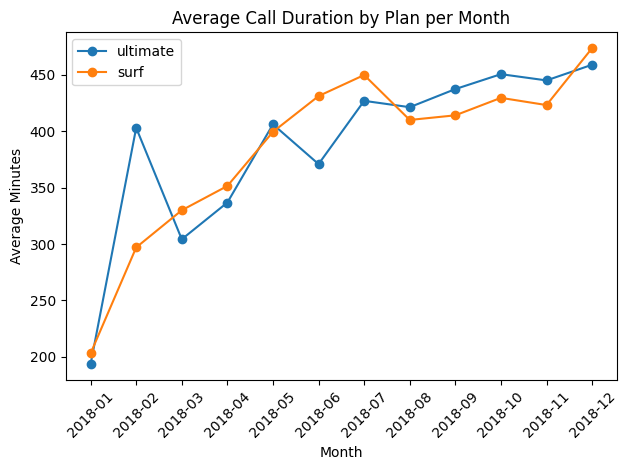

In [ ]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plat to visualize it.
avg_call_duration = monthly_data.groupby(['plan', 'year_month'])['total_minutes'].mean().reset_index()

# Plot bar chart
import matplotlib.pyplot as plt

for plan in monthly_data['plan'].unique():
    plan_data = avg_call_duration[avg_call_duration['plan'] == plan]
    plt.plot(plan_data['year_month'].astype(str), plan_data['total_minutes'], marker='o', label=plan)

plt.xlabel('Month')
plt.ylabel('Average Minutes')
plt.title('Average Call Duration by Plan per Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


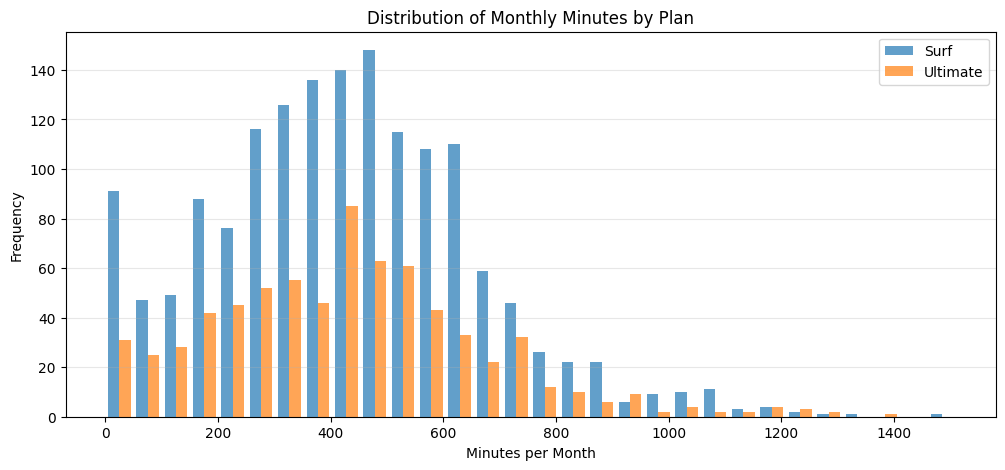

In [ ]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.
surf_minutes = monthly_data[monthly_data['plan'] == 'surf']['total_minutes']
ultimate_minutes = monthly_data[monthly_data['plan'] == 'ultimate']['total_minutes']

plt.figure(figsize=(12, 5))
plt.hist([surf_minutes, ultimate_minutes], bins=30, label=['Surf', 'Ultimate'], alpha=0.7)
plt.xlabel('Minutes per Month')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Minutes by Plan')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


Calculates the mean and the variable of the call duration to reason on whether users on the different plans have different behaviours for their calls.

In [ ]:
# Calculate the mean and the variance of the monthly call duration
print("=== Monthly Call Duration Statistics by Plan ===")
print(monthly_data.groupby('plan')['total_minutes'].agg(['mean', 'var', 'std']))


=== Monthly Call Duration Statistics by Plan ===
           mean      var    std
plan                           
surf     428.75 54968.28 234.45
ultimate 430.45 57844.46 240.51


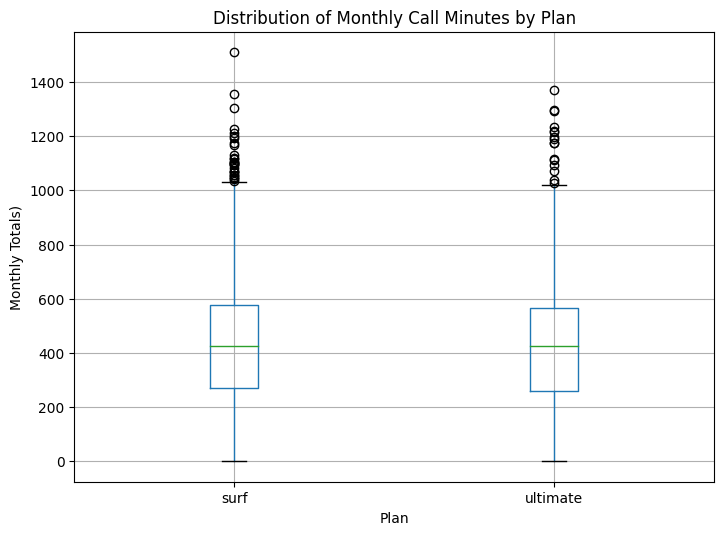

In [ ]:
# Plot a boxplot to visualize the distribution of the monthly call duration
monthly_data.boxplot(column='total_minutes', by='plan', figsize=(8, 6))
plt.title('Distribution of Monthly Call Minutes by Plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Monthly Totals)')
plt.show()


Based on the statistical analysis of calling patterns:
- Call usage for both plans is fairly similar, with most users calling around 300–600 minutes per month.
- Some users in both plans have very high call minutes, more than a 1000 minutes which is an absurdly long phone call.
- Surf and Ultimate users show very similar calling behavior overall.
- Most monthly call usage clusters are more in the mid-range rather than very low or very high values.
- Average call minutes gradually increase throughout the year for both plans.
- There isn't rally a major difference in calling behavior between Surf and Ultimate.

### Messages

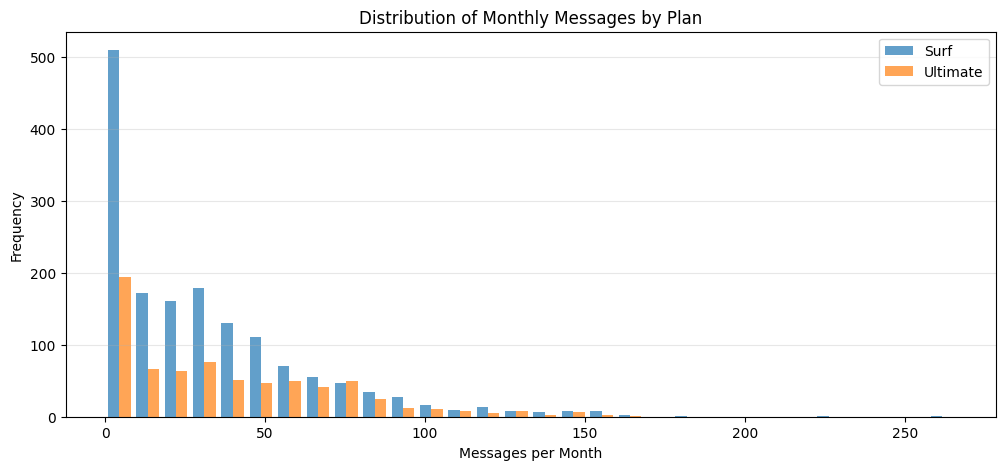

=== Message Statistics by Plan ===
          mean     var   std
plan                        
surf     31.16 1126.72 33.57
ultimate 37.55 1208.76 34.77


In [ ]:
# Compare the number of messages users of each plan tend to send each month
surf_messages = monthly_data[monthly_data['plan'] == 'surf']['total_messages']
ultimate_messages = monthly_data[monthly_data['plan'] == 'ultimate']['total_messages']

plt.figure(figsize=(12, 5))
plt.hist([surf_messages, ultimate_messages], bins=30, label=['Surf', 'Ultimate'], alpha=0.7,)
plt.xlabel('Messages per Month')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Messages by Plan')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("=== Message Statistics by Plan ===")
print(monthly_data.groupby('plan')['total_messages'].agg(['mean', 'var', 'std']))


<Figure size 800x600 with 0 Axes>

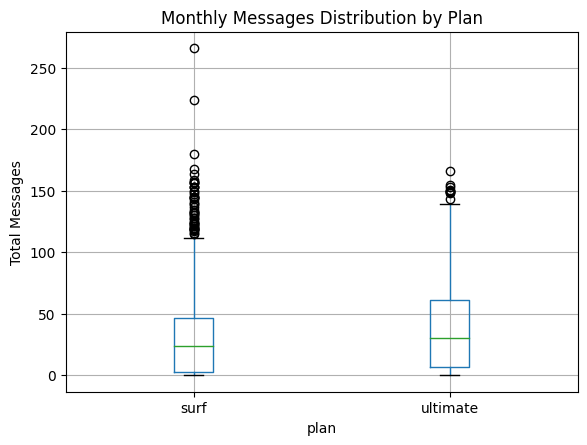

In [ ]:
plt.figure(figsize=(8, 6))
monthly_data.boxplot(column='total_messages', by='plan')
plt.title('Monthly Messages Distribution by Plan')
plt.suptitle('')
plt.ylabel('Total Messages')
plt.show()

In [ ]:
print("=== MESSAGING BEHAVIOR ANALYSIS ===")

# Descriptive statistics by plan
print("\n1. Descriptive Statistics:")
print(monthly_data.groupby('plan')['total_messages'].describe())

# Calculates additional statistics
print("\n2. Additional Statistics:")
message_stats = monthly_data.groupby('plan')['total_messages'].agg([
    'mean', 'median', 'std', 'var', 'min', 'max'
]).round(2)
print(message_stats)

=== MESSAGING BEHAVIOR ANALYSIS ===

1. Descriptive Statistics:
           count  mean   std  min  25%   50%   75%    max
plan                                                     
surf     1573.00 31.16 33.57 0.00 3.00 24.00 47.00 266.00
ultimate  720.00 37.55 34.77 0.00 7.00 30.00 61.00 166.00

2. Additional Statistics:
          mean  median   std     var  min  max
plan                                          
surf     31.16      24 33.57 1126.72    0  266
ultimate 37.55      30 34.77 1208.76    0  166


Based on the statistical analysis of messaging patterns:

- Ultimate plan users send more messages on average (37.55) compared to Surf users (31.16)
- Both plans show similar variability in messaging behavior
- The difference suggests Ultimate users are more engaged with messaging services
- This higher usage aligns with Ultimate being the premium plan

### Internet

In [ ]:
# Compare the amount of internet traffic consumed by users per plan
surf_internet = monthly_data[monthly_data['plan'] == 'surf']['total_gb']
ultimate_internet = monthly_data[monthly_data['plan'] == 'ultimate']['total_gb']
print("=== Internet Usage Statistics by Plan ===")
print(monthly_data.groupby('plan')['total_gb'].agg(['mean', 'var', 'std']))


=== Internet Usage Statistics by Plan ===
          mean   var  std
plan                     
surf     16.67 61.58 7.85
ultimate 17.31 58.83 7.67


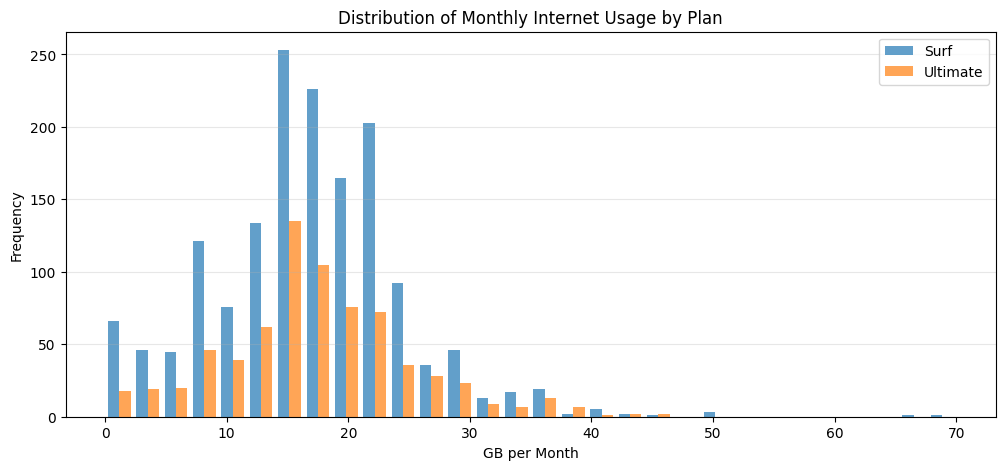

In [ ]:

plt.figure(figsize=(12, 5))
plt.hist([surf_internet, ultimate_internet], bins=30, label=['Surf', 'Ultimate'], alpha=0.7)
plt.xlabel('GB per Month')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Internet Usage by Plan')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


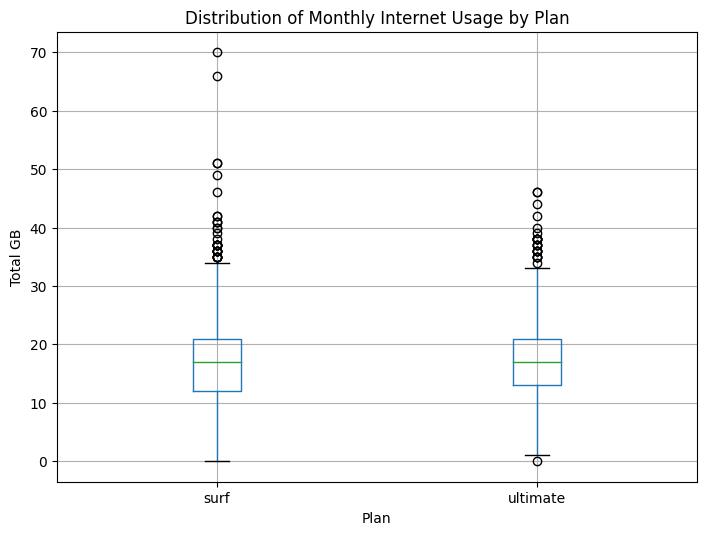

In [ ]:
monthly_data.boxplot(column='total_gb', by='plan', figsize=(8, 6))
plt.title('Distribution of Monthly Internet Usage by Plan')
plt.suptitle('')
plt.xlabel('Plan')
plt.ylabel('Total GB')
plt.show()

Based on the statistical analysis of Internet patterns:

- Surf and Ultimate users exhibit very similar internet consumption behavior. 
- The average usage, spread, and distribution patterns are very similar. 
- Most users consume moderate amounts of data around 10–25 GB per month. 
- The choice of plan does not appear to significantly change typical internet usage patterns.

## Revenue

In [ ]:
# Statistically describe revenue between plans
print("=== Revenue Statistics by Plan ===")
print(monthly_data.groupby('plan')['revenue'].describe())

=== Revenue Statistics by Plan ===
           count  mean   std   min   25%   50%   75%    max
plan                                                       
surf     1573.00 60.71 55.39 20.00 20.00 40.36 80.36 590.37
ultimate  720.00 72.31 11.40 70.00 70.00 70.00 70.00 182.00


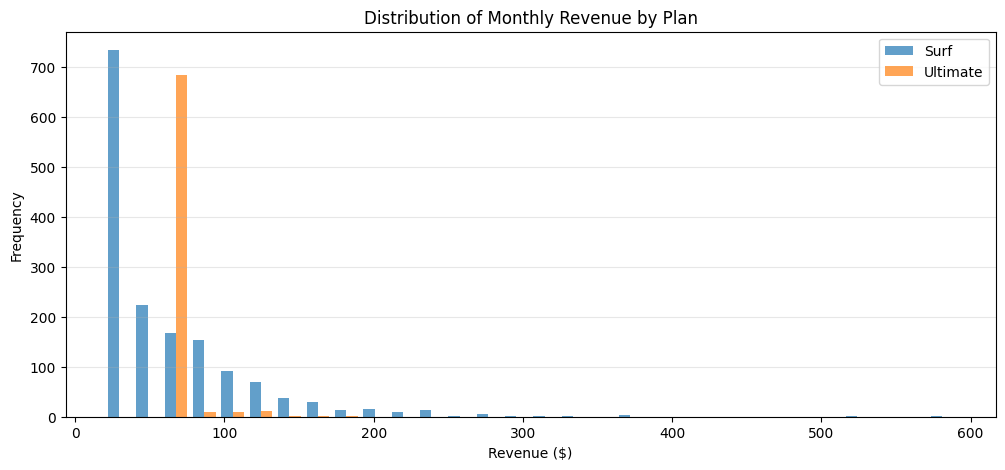

In [ ]:
# Visualize revenue distribution
surf_revenue = monthly_data[monthly_data['plan'] == 'surf']['revenue']
ultimate_revenue = monthly_data[monthly_data['plan'] == 'ultimate']['revenue']

plt.figure(figsize=(12, 5))
plt.hist([surf_revenue, ultimate_revenue], bins=30, label=['Surf', 'Ultimate'], alpha=0.7)
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Revenue by Plan')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

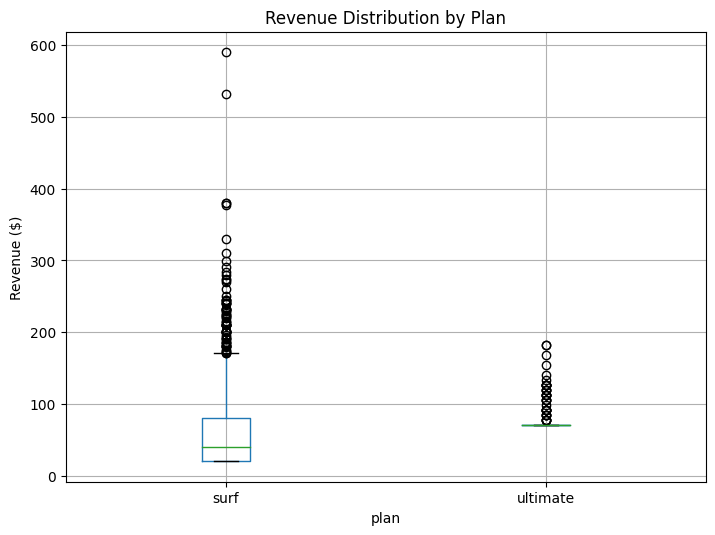

In [ ]:
monthly_data.boxplot(column='revenue', by='plan', figsize=(8, 6))
plt.title('Revenue Distribution by Plan')
plt.suptitle('')
plt.ylabel('Revenue ($)')
plt.show()

Based on the statistical analysis of Revenue patterns:

- Ultimate plan - Generates higher and more stable revenue per user. Most customers pay the fixed monthly fee. Few additional charges

- Surf plan - Generates lower average revenue. Revenue is highly variable. Some users generate very high revenue due to overage fees

## Test statistical hypotheses

I used a two-sample t-test because I wanted to compare the average revenue between two different groups of users on the Surf plan and those on the Ultimate plan. The users in each plan are separate, so the samples are independent. Also, since both groups have more than 30 observations, the t-test is a seemed like a reliable way to compare their average revenues.

In [ ]:
# Test hypothesis: average revenue from Ultimate and Surf differs
from scipy import stats as st

# Separates revenue by plan
surf_revenue = monthly_data[monthly_data['plan'] == 'surf']['revenue']
ultimate_revenue = monthly_data[monthly_data['plan'] == 'ultimate']['revenue']

# Checks assumptions before testing
print("=== Assumption Check ===")
print(f"Sample sizes:")
print(f"  Surf: {len(surf_revenue)}")
print(f"  Ultimate: {len(ultimate_revenue)}")

print(f"\nVariances:")
print(f"  Surf variance: {surf_revenue.var():.2f}")
print(f"  Ultimate variance: {ultimate_revenue.var():.2f}")

# Checks if variances are similar (rule of thumb: ratio should be between 0.5 and 2)
variance_ratio = surf_revenue.var() / ultimate_revenue.var()
print(f"  Variance ratio (Surf/Ultimate): {variance_ratio:.2f}")

# Determines if it should assume equal variances
equal_var = 0.5 <= variance_ratio <= 2
print(f"\nAssume equal variances: {equal_var}")

# Formulates a hypotheses
print("\n=== Hypothesis Test: Surf vs Ultimate Revenue ===")
print("H0 (null): Average revenue from Surf = Average revenue from Ultimate")
print("H1 (alternative): Average revenue from Surf ≠ Average revenue from Ultimate")

# Conducts the test
alpha = 0.05
results = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=equal_var)

print(f"\nAlpha: {alpha}")
print(f"p-value: {results.pvalue:.6f}")

if results.pvalue < alpha:
    print(f"\nConclusion: We reject the null hypothesis")
    print(f"Revenue differs significantly between plans at {alpha} significance level")
else:
    print(f"\nConclusion: We cannot reject the null hypothesis")
    print(f"No significant difference in revenue between plans at {alpha} significance level")



=== Assumption Check ===
Sample sizes:
  Surf: 1573
  Ultimate: 720

Variances:
  Surf variance: 3067.84
  Ultimate variance: 129.85
  Variance ratio (Surf/Ultimate): 23.63

Assume equal variances: False

=== Hypothesis Test: Surf vs Ultimate Revenue ===
H0 (null): Average revenue from Surf = Average revenue from Ultimate
H1 (alternative): Average revenue from Surf ≠ Average revenue from Ultimate

Alpha: 0.05
p-value: 0.000000

Conclusion: We reject the null hypothesis
Revenue differs significantly between plans at 0.05 significance level


Test the hypothesis that the average revenue from users in the NY-NJ area is different from that of the users from the other regions.

like the last statistical hypotheseses resasoning I used a two-sample t-test because the goal was to compare the average revenue between two independent groups, users from the NY-NJ region and users from other regions. Since the users in each region are different, the samples are independent, and the t-test is an appropriate method for comparing the mean revenue of the two groups.

In [ ]:
# Test hypothesis: revenue from NY-NJ differs from other regions

# Checks what the actual city values look like
print("=== City Values Check ===")
print(monthly_data['city'].value_counts())

# Creates NY-NJ filter (use na=False to handle missing values properly)
# Match exact region pattern from dataset
monthly_data['is_ny_nj'] = monthly_data['city'].str.contains('NY-NJ', na=False)

# Verifys the filter worked correctly
print("\n=== Region Split ===")
print(f"NY-NJ users: {monthly_data['is_ny_nj'].sum()}")
print(f"Other regions: {(~monthly_data['is_ny_nj']).sum()}")

# Separates revenue by region
ny_nj_revenue = monthly_data[monthly_data['is_ny_nj'] == True]['revenue']
other_revenue = monthly_data[monthly_data['is_ny_nj'] == False]['revenue']

# Check assumptions
print("\n=== Assumption Check ===")
print(f"Sample sizes:")
print(f"  NY-NJ: {len(ny_nj_revenue)}")
print(f"  Other regions: {len(other_revenue)}")

print(f"\nVariances:")
print(f"  NY-NJ variance: {ny_nj_revenue.var():.2f}")
print(f"  Other regions variance: {other_revenue.var():.2f}")

variance_ratio = ny_nj_revenue.var() / other_revenue.var()
print(f"  Variance ratio (NY-NJ/Other): {variance_ratio:.2f}")

equal_var = 0.5 <= variance_ratio <= 2
print(f"\nAssume equal variances: {equal_var}")

# Formulates a hypotheses
print("\n=== Hypothesis Test: NY-NJ vs Other Regions ===")
print("H0 (null): Average revenue from NY-NJ = Average revenue from other regions")
print("H1 (alternative): Average revenue from NY-NJ ≠ Average revenue from other regions")

# Conducts the test
alpha = 0.05
results = st.ttest_ind(ny_nj_revenue, other_revenue, equal_var=equal_var)

print(f"\nAlpha: {alpha}")
print(f"p-value: {results.pvalue:.6f}")

if results.pvalue < alpha:
    print(f"\nConclusion: We reject the null hypothesis")
    print(f"Revenue differs significantly by region at {alpha} significance level")
    print(f"\nMean comparison:")
    print(f"  NY-NJ mean revenue: ${ny_nj_revenue.mean():.2f}")
    print(f"  Other regions mean revenue: ${other_revenue.mean():.2f}")
else:
    print(f"\nConclusion: We cannot reject the null hypothesis")
    print(f"No significant difference in revenue by region at {alpha} significance level")


=== City Values Check ===
New York-Newark-Jersey City, NY-NJ-PA MSA          377
Los Angeles-Long Beach-Anaheim, CA MSA             132
Chicago-Naperville-Elgin, IL-IN-WI MSA              94
Dallas-Fort Worth-Arlington, TX MSA                 88
Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA     82
                                                  ... 
Omaha-Council Bluffs, NE-IA MSA                      3
Raleigh-Cary, NC MSA                                 2
El Paso, TX MSA                                      2
Jacksonville, FL MSA                                 2
Cape Coral-Fort Myers, FL MSA                        1
Name: city, Length: 73, dtype: int64

=== Region Split ===
NY-NJ users: 377
Other regions: 1916

=== Assumption Check ===
Sample sizes:
  NY-NJ: 377
  Other regions: 1916

Variances:
  NY-NJ variance: 1895.55
  Other regions variance: 2225.05
  Variance ratio (NY-NJ/Other): 0.85

Assume equal variances: True

=== Hypothesis Test: NY-NJ vs Other Regions ===
H0 (null):

## General conclusion

The analysis showed that the Ultimate plan generates higher average revenue per user than the Surf plan, and the hypothesis test confirmed that this difference is statistically significant (p-value = 2.86e-08). This means we can reject the null hypothesis and conclude that the two plans bring in different average revenues. Even though the Surf plan has more users overall, Ultimate customers usually pay the fixed monthly price, which leads to more consistent and predictable revenue per user.

The second hypothesis test compared revenue from users in the NY–NJ region and users in other regions. The results showed no statistically significant difference in revenue between these groups, so we fail to reject the null hypothesis for this test.

Overall, this suggests that the type of plan has a bigger impact on revenue than the user’s location. Based on these findings, Megaline would likely benefit from focusing more of its advertising on the Ultimate plan, since it generates higher revenue per customer regardless of region.